# Laboratorio 2 - Deep Learning
## Modelos LSTM para series de tiempo

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Ejercicio 1

## 1.1
### Carga de las series a analizar

In [2]:
train = pd.read_csv(
    "total_train.csv",
    index_col=0,
    parse_dates=True
)

test = pd.read_csv(
    "total_test.csv",
    index_col=0,
    parse_dates=True
)

train = train["viajeros"]
test = test["viajeros"]

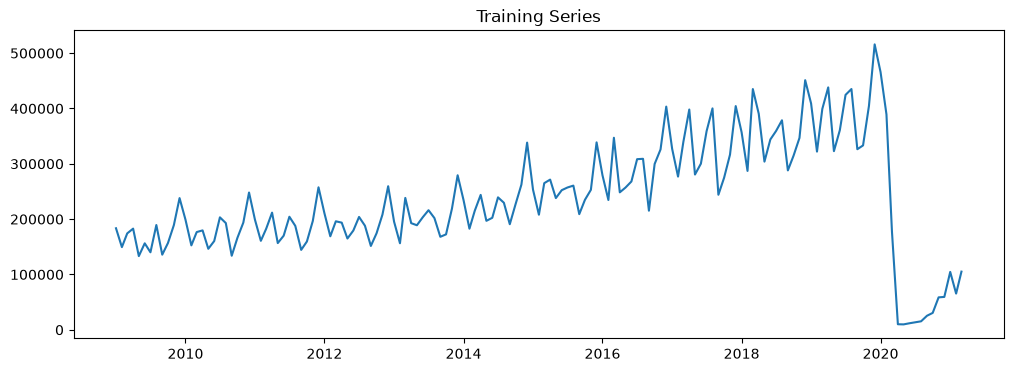

In [3]:
plt.figure(figsize=(12,4))
plt.plot(train)
plt.title("Training Series")
plt.show()

### Normalización

In [4]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
test_scaled = scaler.transform(test.values.reshape(-1,1))

### Ventanas de tiempo
Se utilizarán los últimos 12 meses para predecir el siguiente mes

In [8]:
LOOK_BACK = 12

def create_dataset(data, look_back):

    X = []
    y = []

    for i in range(len(data)-look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])

    return np.array(X), np.array(y)

In [9]:
X_train, y_train = create_dataset(train_scaled, LOOK_BACK)
X_test, y_test = create_dataset(test_scaled, LOOK_BACK)

In [10]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

### Carga de datos

In [11]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=8,
    shuffle=False
)

### Clase de LSTM para los 2 modelos

In [12]:
class LSTMModel(nn.Module):

    def __init__(self, hidden):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden,
            batch_first=True
        )

        self.fc = nn.Linear(hidden,1)

    def forward(self,x):

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        return self.fc(out)

### Función de entrenamiento

In [13]:
def train_model(model, epochs):

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    losses = []

    for epoch in range(epochs):

        model.train()

        epoch_loss = 0

        for X,y in train_loader:

            optimizer.zero_grad()

            pred = model(X)

            loss = criterion(pred,y)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss)

    return losses

## 1.2 Modelos LSTM

#### Modelo 1

In [14]:
model1 = LSTMModel(hidden=32)

loss1 = train_model(
    model1,
    epochs=50
)

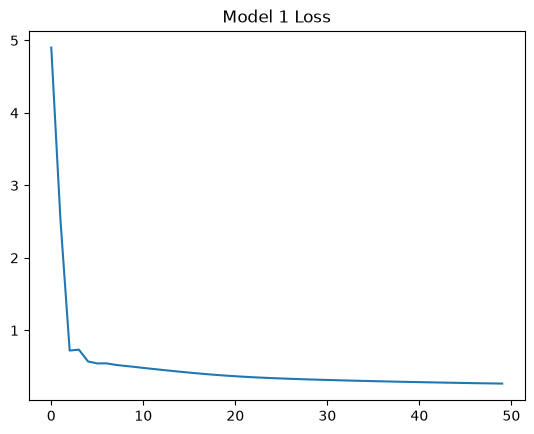

In [15]:
plt.plot(loss1)
plt.title("Model 1 Loss")
plt.show()

#### Modelo 2

Incluye cambio de parámetros en hidden units y epochs.

In [16]:
model2 = LSTMModel(hidden=64)

loss2 = train_model(
    model2,
    epochs=100
)

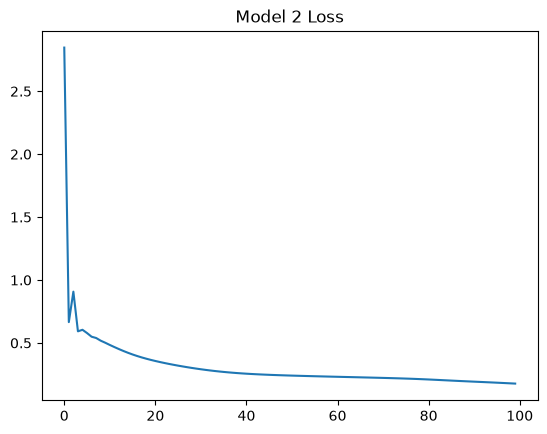

In [17]:
plt.plot(loss2)
plt.title("Model 2 Loss")
plt.show()

## 1.3 Predicciones
### Función de predicción

In [30]:
def predict(model,X):

    model.eval()

    with torch.no_grad():

        pred = model(X).numpy()

    return scaler.inverse_transform(pred)

pred1 = predict(model1,X_test)
pred2 = predict(model2,X_test)

real = scaler.inverse_transform(y_test.numpy())

In [32]:
## METRICAS
def evaluate(real,pred):

    rmse = np.sqrt(mean_squared_error(real,pred))
    mae = mean_absolute_error(real,pred)

    mape = np.mean(
        np.abs((real-pred)/real)
    )*100

    return rmse,mae,mape

rmse1,mae1,mape1 = evaluate(real,pred1)
rmse2,mae2,mape2 = evaluate(real,pred2)

results = pd.DataFrame({

    "Model":[
        "LSTM 1",
        "LSTM 2"
    ],

    "RMSE":[
        rmse1,
        rmse2
    ],

    "MAE":[
        mae1,
        mae2
    ],

    "MAPE":[
        mape1,
        mape2
    ]
})

results

,Model,RMSE,MAE,MAPE
0,LSTM 1,61247.14315,47198.175781,15.393700
1,LSTM 2,54220.53456,41433.281250,13.682407


### Predicciones: visualización

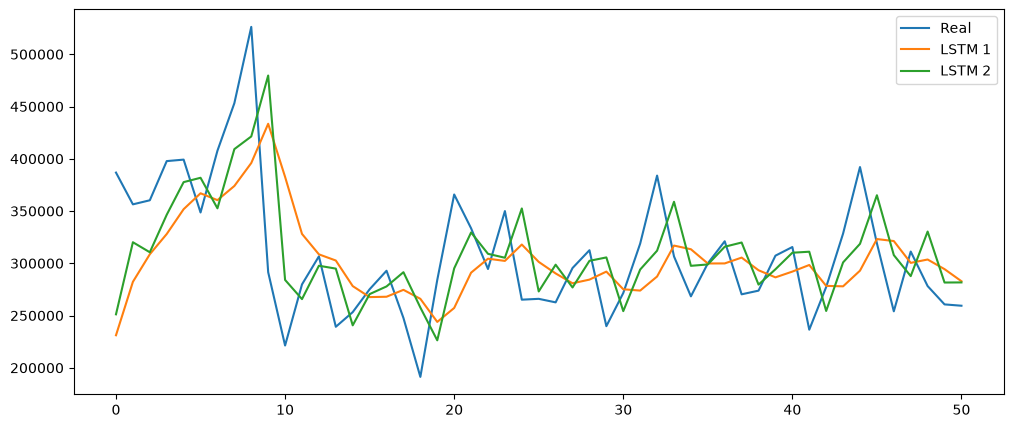

In [33]:
plt.figure(figsize=(12,5))

plt.plot(real,label="Real")

plt.plot(pred1,label="LSTM 1")

plt.plot(pred2,label="LSTM 2")

plt.legend()

plt.show()

In [34]:
best = results.loc[results["RMSE"].idxmin()]

print(best)

Model         LSTM 2
RMSE     54220.53456
MAE      41433.28125
MAPE       13.682407
Name: 1, dtype: object


Es evidente que el modelo 2 presentó mayor precisión por la escala de su error medio.

In [35]:
comparison = pd.DataFrame({

    "Model":[
        "Holt-Winters",
        "LSTM 1",
        "LSTM 2"
    ],

    "RMSE":[
        168288.8,     
        rmse1,
        rmse2
    ],

    "MAE":[
        148782.5,     
        mae1,
        mae2
    ],

    "MAPE":[
        48.8,     
        mape1,
        mape2
    ]



})

comparison

,Model,RMSE,MAE,MAPE
0,Holt-Winters,168288.80000,148782.500000,48.800000
1,LSTM 1,61247.14315,47198.175781,15.393700
2,LSTM 2,54220.53456,41433.281250,13.682407


A comparación del modelo de Holt-Winters, ambos modelos de Deep Learning evidencian un mayor rendimiento para hacer predicciones. Ahora, entre dichos modelos, el segundo resultó ser el mejor candidato porque cuenta con un mayor número de neuronas y más épocas de entrenamiento, lo que le permite aprender patrones temporales más complejos, como la tendencia y la estacionalidad presentes en la serie de viajeros. 

En este caso el Modelo 2, que tiene arquitectura de mayor complejidad fue necesaria para generalizar la predicción.